# Agent turning

Note: This notebook only uses data from the agents trained with seed 17. It does not include runs with other seeds.

In [2]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [4]:
data_folder = '/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=43)

filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_4/2026-04-28_19-57-43_M22_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260418_1/2026-04-28_18-35-32_M23_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/da

In [5]:
dropped_trials = 1

In [6]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 539
First trial end event found at index: 545
First trial end event found at index: 539
First trial end event found at index: 555
First trial end event found at index: 556
First trial end event found at index: 557
First trial end event found at index: 553
First trial end event found at index: 547
First trial end event found at index: 576
First trial end event found at index: 547
First trial end event found at index: 518
First trial end event found at index: 519
First trial end event found at index: 545
First trial end event found at index: 553
First trial end event found at index: 578
First trial end event found at index: 546
First trial end event found at index: 533
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 538
First trial end event found at index: 538
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at ind

In [7]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

### Parameter value extraction

In [9]:
import agent_analysis.functions.preprocessing as prep

In [10]:
_, step_penalties = prep.extract_step_penalties(data_folder, yaml_filename=None)

## Turning magnitude after slice onset
how much the agent rotates in a fixed early window after slice onset

In [8]:
player_id = 0

In [11]:
len(trial_lists)

33

Extract head angles from slice onset to trigger activation. 

Note that the function extracts them in radians

In [11]:
head_angles_sessions = {}

for trial_list_index, trial_list in enumerate(trial_lists):
    head_angles_trials = {}

    for trial_index, trial in enumerate(trial_list):
        head_angles = trajectory_vectors.extract_trial_player_headangles(trial_list, trial_index, trial, player_id)
        
        head_angles = np.array(head_angles, dtype=float)

        head_angles_trials[trial_index] = head_angles
        
    head_angles_sessions[trial_list_index] = head_angles_trials

In [12]:
time_window = 10

In [13]:
turning_magnitude_dict = {}
mean_turning_magnitude_dict = {}

for session_id, trials in head_angles_sessions.items():
    turning_magnitude_dict[session_id] = []

    for trial_id, angles_rad in trials.items():
        angles_rad = np.array(angles_rad)

        angles_window = angles_rad[:time_window]

        angles_window = angles_window[~np.isnan(angles_window)]
        
        # unwrap angles so 359 -> 0 transition is not a large jump
        angles_unwrapped = np.rad2deg(np.unwrap(angles_window))

        # frame-to-fram turning
        angle_diffs = np.diff(angles_unwrapped)

        # total amount turned in degrees
        total_turning = np.sum(np.abs(angle_diffs))

        turning_magnitude_dict[session_id].append(total_turning)

    mean_turning_magnitude_dict[session_id] = np.nanmean(turning_magnitude_dict[session_id])

In [14]:
# collect average centrality for each session, sorted by step penalty
mean_turning_list = []
std_turning_list = []
sem_turning_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_turning_magnitude_dict.keys()), key=lambda x: x[0]):
    
    values = np.array(turning_magnitude_dict[session_id], dtype=float)
    mean_turning_list.append(np.mean(values))
    std_turning_list.append(np.std(values))
    sem_turning_list.append(np.nanstd(values) / np.sqrt(np.sum(~np.isnan(values))))
    sorted_penalties.append(penalty)

In [212]:
max(mean_turning_list), min(mean_turning_list)

(np.float64(60.06847524094033), np.float64(9.006743704335074))

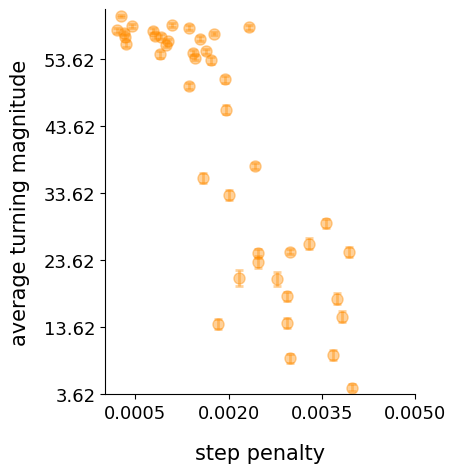

In [15]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    mean_turning_list,
    yerr=sem_turning_list,
    fmt='o',
    alpha=0.4,
    color="darkorange",
    markersize=8,

    ecolor='darkorange',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("average turning magnitude", fontsize=15, labelpad=10)

plt.ylim([min(mean_turning_list) - 1, max(mean_turning_list) + 1])
plt.yticks(np.arange(min(mean_turning_list) - 1, max(mean_turning_list) + 1, 10), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

### box plots

In [51]:
penalties = np.array(sorted_penalties)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

In [52]:
low_group = []
mid_low_group = []
mid_high_group = []
high_group = []

In [53]:
for penalty, session_id in sorted(
    zip(step_penalties, mean_turning_magnitude_dict.keys()),
    key=lambda x: x[0]
):

    values = np.array(mean_turning_magnitude_dict[session_id], dtype=float)
    values = values[~np.isnan(values)]

    if penalty <= low_thresh:
        low_group.extend(values)

    elif penalty <= mid_thresh:
        mid_low_group.extend(values)

    elif penalty <= high_thresh:
        mid_high_group.extend(values)

    else:
        high_group.extend(values)

In [54]:
from scipy.stats import kruskal, mannwhitneyu

In [55]:
data = [
    low_group,
    mid_low_group,
    mid_high_group,
    high_group
]

In [56]:
# overall test
stat, p = kruskal(low_group, mid_low_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise tests
p_low_midlow = mannwhitneyu(low_group, mid_low_group).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_group, mid_high_group).pvalue
p_midhigh_high = mannwhitneyu(mid_high_group, high_group).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_group, mid_high_group).pvalue
p_midlow_high = mannwhitneyu(mid_low_group, high_group).pvalue
p_low_high = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 2.4417479573635292e-06


In [16]:
def add_sig_bar(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c='black')

    if p < 0.001:
        text = '***'
    elif p < 0.01:
        text = '**'
    elif p < 0.05:
        text = '*'
    else:
        text = 'n.s.'

    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

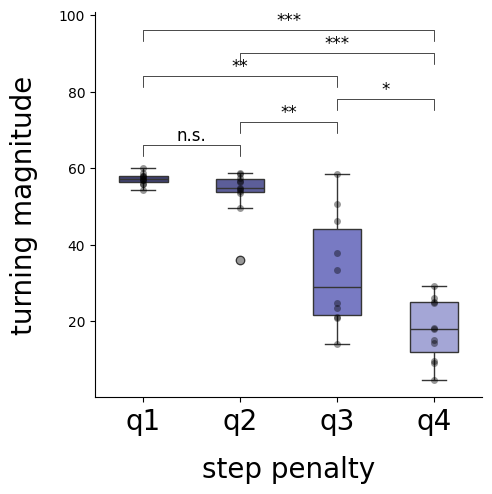

In [57]:
palette = sns.color_palette("tab20b", 4)

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)

plt.ylabel("turning magnitude", fontsize=20, labelpad=15)
plt.xlabel("step penalty", fontsize=20, labelpad=15)

ax = plt.gca()

y_max = max([np.max(g) for g in data if len(g) > 0])
h = y_max * 0.05

add_sig_bar(ax, 0, 1, y_max + h, h, p_low_midlow)
add_sig_bar(ax, 1, 2, y_max + 3*h, h, p_midlow_midhigh)
add_sig_bar(ax, 2, 3, y_max + 5*h, h, p_midhigh_high)

# optional broader comparisons
add_sig_bar(ax, 0, 2, y_max + 7*h, h, p_low_midhigh)
add_sig_bar(ax, 1, 3, y_max + 9*h, h, p_midlow_high)
add_sig_bar(ax, 0, 3, y_max + 11*h, h, p_low_high)

sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

sns.despine(top=True, right=True)

plt.show()

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_11196/4013327079.py:5: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  sns.boxplot(data=data, width=0.5, palette=palette)


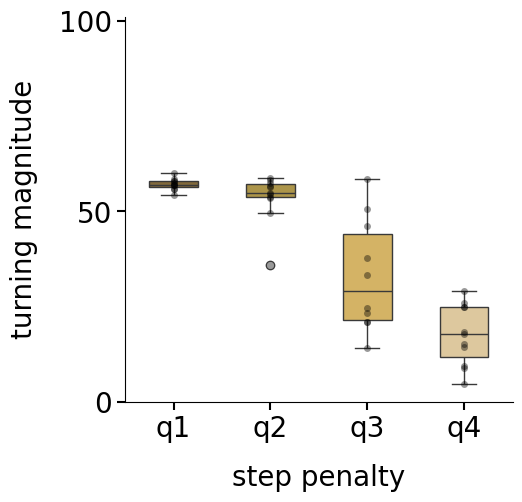

In [62]:
palette = sns.color_palette("tab20b")[8::]

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)

plt.ylabel("turning magnitude", fontsize=20, labelpad=15)
plt.xlabel("step penalty", fontsize=20, labelpad=15)
plt.ylim([0, 101])
plt.yticks(np.arange(0, 101, 50), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

sns.despine(top=True, right=True)

plt.show()

## Turning rate after slice onset

In [26]:
turning_magnitude_dict_all = {}
mean_turning_magnitude_dict_all = {}
duration = {}

for session_id, trials in head_angles_sessions.items():
    turning_magnitude_dict_all[session_id] = []
    duration[session_id] = []

    for trial_id, angles_rad in trials.items():
        angles_rad = np.array(angles_rad)

        angles_rad = angles_rad[~np.isnan(angles_rad)]
        
        # unwrap angles so 359 -> 0 transition is not a large jump
        angles_unwrapped = np.rad2deg(np.unwrap(angles_rad))

        # frame-to-fram turning
        angle_diffs = np.diff(angles_unwrapped)

        # total amount turned in degrees
        total_turning = np.sum(np.abs(angle_diffs))

        turning_magnitude_dict_all[session_id].append(total_turning)
        duration[session_id].append(len(angles_rad))

    mean_turning_magnitude_dict_all[session_id] = np.nanmean(turning_magnitude_dict_all[session_id])

In [252]:
duration

{0: [129,
  132,
  100,
  115,
  104,
  106,
  100,
  97,
  110,
  132,
  123,
  117,
  108,
  80,
  98,
  93,
  88,
  97,
  95,
  87,
  115,
  158,
  119,
  129,
  145,
  89,
  84,
  106,
  83,
  87,
  88,
  127,
  97,
  123,
  100,
  107,
  102,
  109,
  101,
  111,
  97,
  96,
  122,
  119,
  170,
  135,
  119,
  101,
  102,
  100,
  91,
  95,
  97,
  92,
  86,
  100,
  102,
  118,
  90,
  103,
  106,
  104,
  119,
  90,
  125,
  93,
  120,
  99,
  102,
  121,
  119,
  90,
  101,
  81,
  128,
  100,
  111,
  108,
  117,
  114,
  160,
  103,
  119,
  124,
  91,
  124,
  88,
  97,
  113,
  103,
  104,
  117,
  96,
  108,
  135,
  110,
  108,
  109,
  95,
  109,
  101,
  110,
  98,
  179,
  106,
  101,
  119,
  124,
  95,
  188,
  102,
  99,
  144,
  116,
  108,
  114,
  99,
  129,
  109,
  107,
  96,
  114,
  122,
  138,
  130,
  109,
  109,
  93,
  113,
  134,
  112,
  106,
  135,
  89,
  97,
  113,
  120,
  105,
  133,
  97,
  102,
  118,
  104,
  137,
  108,
  87,
  110,
  90,
  12

In [27]:
# collect average centrality for each session, sorted by step penalty
mean_turning_rate_dict = {}
mean_turning_rate_list = []
std_turning_rate_list = []
sem_turning_rate_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_turning_magnitude_dict_all.keys()), key=lambda x: x[0]):

    
    values = np.array(turning_magnitude_dict_all[session_id], dtype=float)

    # this will be a list of turning rates for each trial in a session
    turning_rates = []

    for i in range(len(duration[session_id])):
        dt = duration[session_id][i] * 0.02
        
        # here I divide the turning magnitudes from each trial by the respective trial time
        turning_rates.append(values[i]/dt)

    print(f"Number of turning rates this session: {len(turning_rates)} \n Average turning rate this session {np.nanmean(turning_rates)}")

    mean_turning_rate_dict[session_id] = turning_rates
    mean_turning_rate_list.append(np.nanmean(turning_rates))
    std_turning_rate_list.append(np.nanstd(turning_rates))
    sem_turning_rate_list.append(np.nanstd(turning_rates) / np.sqrt(np.sum(~np.isnan(turning_rates))))
    sorted_penalties.append(penalty)

Number of turning rates this session: 667 
 Average turning rate this session 175.61724247682903
Number of turning rates this session: 1998 
 Average turning rate this session 282.4126728442065
Number of turning rates this session: 665 
 Average turning rate this session 168.35906992195032
Number of turning rates this session: 670 
 Average turning rate this session 254.9899053666614
Number of turning rates this session: 674 
 Average turning rate this session 165.41348712637526
Number of turning rates this session: 667 
 Average turning rate this session 171.42609144980236
Number of turning rates this session: 658 
 Average turning rate this session 231.43304352640732
Number of turning rates this session: 511 
 Average turning rate this session 230.97281471716474
Number of turning rates this session: 521 
 Average turning rate this session 144.9353521760309
Number of turning rates this session: 568 
 Average turning rate this session 253.23476295857836
Number of turning rates this ses

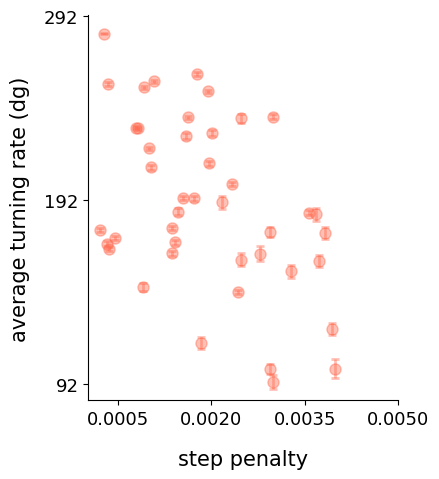

In [28]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    mean_turning_rate_list,
    yerr=sem_turning_rate_list,
    fmt='o',
    alpha=0.4,
    color="tomato",
    markersize=8,

    ecolor='tomato',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("average turning rate (dg)", fontsize=15, labelpad=10)

plt.ylim([min(mean_turning_rate_list) - 10, max(mean_turning_rate_list) + 10])
plt.yticks(np.arange(min(mean_turning_rate_list) - 1, max(mean_turning_rate_list) + 10, 100), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

### box plots

In [36]:
penalties = np.array(sorted_penalties)
means = np.array(mean_turning_rate_list)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

low_group = means[penalties <= low_thresh]
mid_low_group = means[(penalties > low_thresh) & (penalties <= mid_thresh)]
mid_high_group = means[(penalties > mid_thresh) & (penalties <= high_thresh)]
high_group = means[penalties > high_thresh]

data = [
    low_group,
    mid_low_group,
    mid_high_group,
    high_group
]

# overall
stat, p = kruskal(low_group, mid_low_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise
p_low_midlow = mannwhitneyu(low_group, mid_low_group).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_group, mid_high_group).pvalue
p_midhigh_high = mannwhitneyu(mid_high_group, high_group).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_group, mid_high_group).pvalue
p_midlow_high = mannwhitneyu(mid_low_group, high_group).pvalue
p_low_high = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 0.032736211490984844


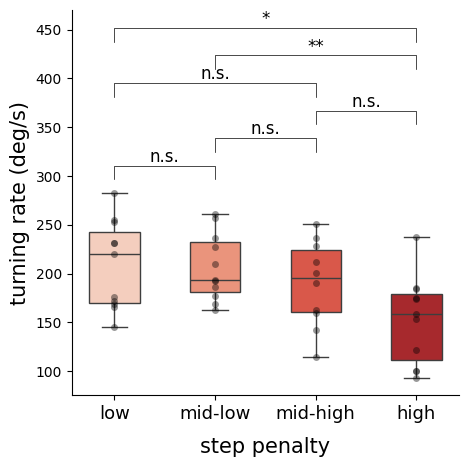

In [37]:
palette = sns.color_palette("Reds", 4)

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks(
    [0, 1, 2, 3],
    ['low', 'mid-low', 'mid-high', 'high'],
    fontsize=13
)

plt.ylabel("turning rate (deg/s)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(means)
h = y_max * 0.05

add_sig_bar(ax, 0, 1, y_max + h, h, p_low_midlow)
add_sig_bar(ax, 1, 2, y_max + 3*h, h, p_midlow_midhigh)
add_sig_bar(ax, 2, 3, y_max + 5*h, h, p_midhigh_high)

# optional broader comparisons
add_sig_bar(ax, 0, 2, y_max + 7*h, h, p_low_midhigh)
add_sig_bar(ax, 1, 3, y_max + 9*h, h, p_midlow_high)
add_sig_bar(ax, 0, 3, y_max + 11*h, h, p_low_high)

plt.show()

## Turning initiation latency

In [29]:
def turn_latency_from_angles(angles_deg, dt=0.02, threshold=30):
    angles = np.array(angles_deg, dtype=float)
    angles = angles[~np.isnan(angles)]

    if len(angles) < 2:
        return np.nan

    #print(angles)
    
    # unwrap for correct differences
    angles_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(angles)))
    #print(angles_unwrapped)

    # per-frame angular change (degrees per frame)
    angle_diffs = np.diff(angles_unwrapped)
    #print(angle_diffs)

    # angular velocity (deg/s)
    angular_velocity = np.abs(angle_diffs) / dt
    #print(angular_velocity)

    # first index where turning exceeds threshold
    idx = np.where(angular_velocity > threshold)[0]

    if len(idx) == 0:
        return np.nan

    first_idx = idx[0] + 1  # +1 because diff shifts index

    # convert index to time
    latency = first_idx * dt
    return latency

In [30]:
turn_latency_dict = {}

for session_id, trials in head_angles_sessions.items():
    turn_latency_dict[session_id] = []

    for trial_id, angles in trials.items():
        # e.g. first 10 samples after slice onset
        angles_window = np.array(angles[:10], dtype=float)
        angles_window = np.rad2deg(angles_window)

        latency = turn_latency_from_angles(
            angles_window,
            dt=0.02,
            threshold=30
        )

        turn_latency_dict[session_id].append(latency)

In [31]:
mean_turn_latency_dict = {
    sid: np.nanmean(vals)
    for sid, vals in turn_latency_dict.items()
}

In [32]:
turning_latencies = turn_latency_dict[0]

In [33]:
# collect average centrality for each session, sorted by step penalty
mean_turning_latency_list = []
std_turning_latency_list = []
sem_turning_latency_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_turn_latency_dict.keys()), key=lambda x: x[0]):

    
    turning_latencies = turn_latency_dict[session_id]

    mean_turning_latency_list.append(np.nanmean(turning_latencies))
    std_turning_latency_list.append(np.nanstd(turning_latencies))
    sem_turning_latency_list.append(np.nanstd(turning_latencies) / np.sqrt(np.sum(~np.isnan(turning_latencies))))
    sorted_penalties.append(penalty)

In [34]:
min(mean_turning_latency_list)

np.float64(0.02127127127127127)

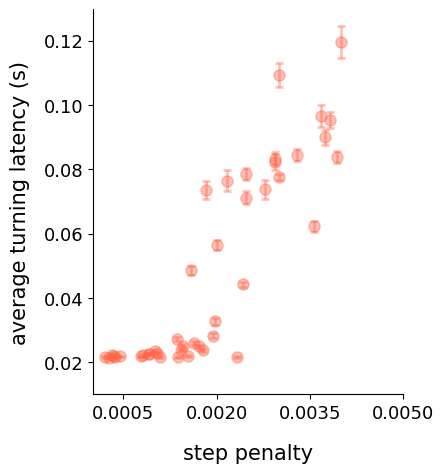

In [65]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    mean_turning_latency_list,
    yerr=sem_turning_latency_list,
    fmt='o',
    alpha=0.4,
    color="tomato",
    markersize=8,

    ecolor='tomato',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("average turning latency (s)", fontsize=15, labelpad=10)

plt.ylim([0.01, max(mean_turning_latency_list) + 0.01])
plt.yticks(np.arange(0.02, max(mean_turning_latency_list) + 0.01, 0.02), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

In [66]:
penalties = np.array(sorted_penalties)
means = np.array(mean_turning_latency_list)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

low_group = means[penalties <= low_thresh]
mid_low_group = means[(penalties > low_thresh) & (penalties <= mid_thresh)]
mid_high_group = means[(penalties > mid_thresh) & (penalties <= high_thresh)]
high_group = means[penalties > high_thresh]

data = [
    low_group,
    mid_low_group,
    mid_high_group,
    high_group
]

# overall
stat, p = kruskal(low_group, mid_low_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise
p_low_midlow = mannwhitneyu(low_group, mid_low_group).pvalue
p_midlow_midhigh = mannwhitneyu(mid_low_group, mid_high_group).pvalue
p_midhigh_high = mannwhitneyu(mid_high_group, high_group).pvalue

# optional broader comparisons
p_low_midhigh = mannwhitneyu(low_group, mid_high_group).pvalue
p_midlow_high = mannwhitneyu(mid_low_group, high_group).pvalue
p_low_high = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 4.875321149935905e-07


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_11196/2184362902.py:5: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(data=data, width=0.5, palette=palette)


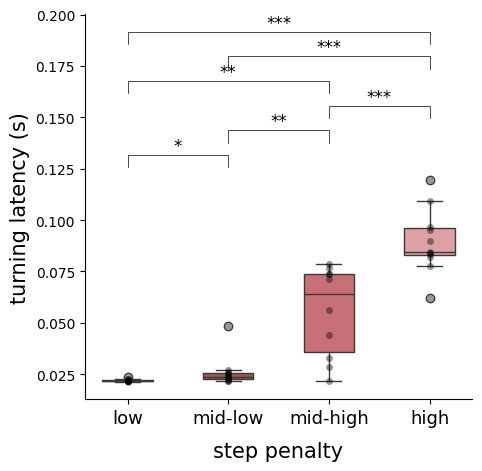

In [67]:
palette = sns.color_palette("tab20b")[12::]

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks(
    [0, 1, 2, 3],
    ['low', 'mid-low', 'mid-high', 'high'],
    fontsize=13
)

plt.ylabel("turning latency (s)", fontsize=15)
plt.xlabel("step penalty", fontsize=15, labelpad=10)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(means)
h = y_max * 0.05

add_sig_bar(ax, 0, 1, y_max + h, h, p_low_midlow)
add_sig_bar(ax, 1, 2, y_max + 3*h, h, p_midlow_midhigh)
add_sig_bar(ax, 2, 3, y_max + 5*h, h, p_midhigh_high)

# optional broader comparisons
add_sig_bar(ax, 0, 2, y_max + 7*h, h, p_low_midhigh)
add_sig_bar(ax, 1, 3, y_max + 9*h, h, p_midlow_high)
add_sig_bar(ax, 0, 3, y_max + 11*h, h, p_low_high)

plt.show()

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_11196/952771840.py:5: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(data=data, width=0.5, palette=palette)


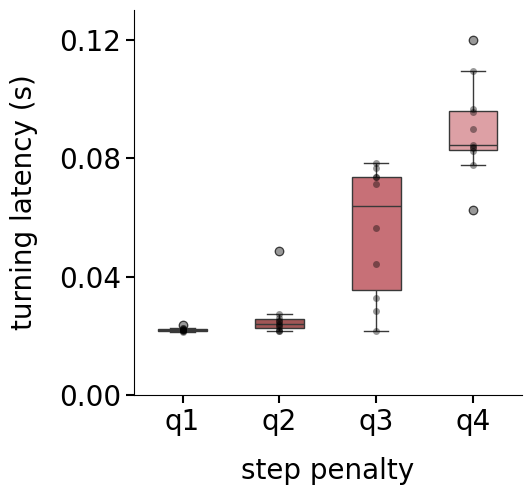

In [69]:
palette = sns.color_palette("tab20b")[12::]

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks(
    [0, 1, 2, 3],
    ['q1','q2','q3','q4'],
    fontsize=20
)
plt.ylim([0, 0.13])
plt.yticks(np.arange(0, 0.13, 0.04), fontsize=20)

plt.ylabel("turning latency (s)", fontsize=20, labelpad=15)
plt.xlabel("step penalty", fontsize=20, labelpad=15)

sns.despine(top=True, right=True)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

plt.show()